## Лабораторная работа № 1 
## Выполнение разведочного анализа данных с помощью PySpark

В данной работе используется датасет с информацией о о 1 миллионе фильмов.  
Источник: https://www.kaggle.com/datasets/alanvourch/tmdb-movies-daily-updates/discussion/573360  
Этот набор данных содержит подробные метаданные о более чем 1 миллионе фильмов из базы данных The Movie Database (TMDB), которые обновляются ежедневно. Он включает в себя такую информацию о фильмах, как названия, жанры, рейтинги, съемочная группа, актерский состав, бюджеты,кассовые сборы и т.д. Полезен для анализа фильмов, рекомендательных систем, анализа тенденций и составления производственных профилей.

Подключим необходимые библиотеки.

In [1]:
import pandas as pd
from pyspark.sql import SparkSession

from pyspark.sql.types import IntegerType, FloatType, DateType
from pyspark.sql.functions import col, to_date, sum, when

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from pyspark.sql import DataFrame

Инициализируем сеанс Spark.

In [2]:
spark = SparkSession.builder.appName("MoviesAnalysis").getOrCreate()

Загрузим набор данных в фрейм данных pyspark.

In [3]:
df = spark.read.option("header", "true").option("inferSchema", "true").csv("TMDB_all_movies.csv")

### Типы признаков в датасете

In [4]:
print('Обзор данных')
df.printSchema()

Обзор данных
root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- vote_average: string (nullable = true)
 |-- vote_count: string (nullable = true)
 |-- status: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- revenue: string (nullable = true)
 |-- runtime: string (nullable = true)
 |-- budget: string (nullable = true)
 |-- imdb_id: string (nullable = true)
 |-- original_language: string (nullable = true)
 |-- original_title: string (nullable = true)
 |-- overview: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- tagline: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- production_companies: string (nullable = true)
 |-- production_countries: string (nullable = true)
 |-- spoken_languages: string (nullable = true)
 |-- cast: string (nullable = true)
 |-- director: string (nullable = true)
 |-- director_of_photography: string (nullable = true)
 |-- writers: string (nullable = true)
 |-- produce

Обзор столбцов

In [5]:
pd.DataFrame(df.dtypes, columns = ['Column Name','Data type'])

,Column Name,Data type
0,id,string
1,title,string
2,vote_average,string
3,vote_count,string
4,status,string
5,release_date,string
6,revenue,string
7,runtime,string
8,budget,string
9,imdb_id,string


Все колонки определяются как строки (string), хотя многие из них должны быть числами.  
Преобразуем:  

In [6]:
df = df.withColumn("vote_count", col("vote_count").cast(IntegerType())) # vote_count в IntegerType 
df = df.withColumn("revenue", col("revenue").cast(IntegerType())) # revenue в IntegerType 
df = df.withColumn("runtime", col("runtime").cast(IntegerType())) # runtime в IntegerType
df = df.withColumn("budget", col("budget").cast(IntegerType())) # budget в IntegerType 
df = df.withColumn("imdb_votes", col("imdb_votes").cast(IntegerType())) # imdb_votes в IntegerType

df = df.withColumn("vote_average", col("vote_average").cast(FloatType())) # vote_average в FloatType 
df = df.withColumn("popularity", col("popularity").cast(FloatType())) # popularity в FloatType
df = df.withColumn("imdb_rating", col("imdb_rating").cast(FloatType())) # imdb_rating в FloatType  

df = df.withColumn("release_date", to_date(col("release_date"), "yyyy-MM-dd")) # release_date в DateType формата yyyy-MM-dd

Обзор столбцов

In [7]:
pd.DataFrame(df.dtypes, columns = ['Column Name','Data type'])

,Column Name,Data type
0,id,string
1,title,string
2,vote_average,float
3,vote_count,int
4,status,string
5,release_date,date
6,revenue,int
7,runtime,int
8,budget,int
9,imdb_id,string


Отобразим первые несколько строк.

In [8]:
pd.set_option('display.max_columns', None) # без автоматического сокращения
df.limit(5).toPandas()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,cast,director,director_of_photography,writers,producers,music_composer,imdb_rating,imdb_votes,poster_path
0,2,Ariel,7.100,367,Released,1988-10-21,0,73,0,tt0094675,fi,Ariel,A Finnish man goes to the city to find a job a...,4.1418,None,"Comedy, Drama, Romance, Crime",Villealfa Filmproductions,Finland,suomi,"Tarja Keinänen, Marja Packalén, Kari Helaseppä...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Aki Kaurismäki,None,7.4,9646.0,/ojDg0PGvs6R9xYFodRct2kdI6wC.jpg
1,3,Shadows in Paradise,7.300,430,Released,1986-10-17,0,74,0,tt0092149,fi,Varjoja paratiisissa,"Nikander, a rubbish collector and would-be ent...",5.4837,None,"Comedy, Drama, Romance",Villealfa Filmproductions,Finland,"svenska, suomi, English","Haije Alanoja, Mari Rantasila, Matti Pellonpää...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Mika Kaurismäki,None,7.4,8524.0,/nj01hspawPof0mJmlgfjuLyJuRN.jpg
2,5,Four Rooms,5.891,2804,Released,1995-12-09,4257354,98,4000000,tt0113101,en,Four Rooms,It's Ted the Bellhop's first night on the job....,2.6289,Twelve outrageous guests. Four scandalous requ...,Comedy,"Miramax, A Band Apart",United States of America,English,"Quinn Hellerman, Kimberly Blair, Sammi Davis, ...","Robert Rodriguez, Quentin Tarantino, Allison A...","Rodrigo García, Guillermo Navarro, Phil Parmet...","Robert Rodriguez, Quentin Tarantino, Allison A...","Lawrence Bender, Quentin Tarantino, Alexandre ...",Combustible Edison,6.7,116529.0,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg
3,6,Judgment Night,6.500,360,Released,1993-10-15,12136938,109,21000000,tt0107286,en,Judgment Night,"Four young friends, while taking a shortcut en...",4.2730,Don't move. Don't whisper. Don't even breathe.,"Action, Crime, Thriller","Largo Entertainment, JVC, Universal Pictures",United States of America,English,"Doug Wert, Angela Alvarado, Everlast, Sean O'G...",Stephen Hopkins,Peter Levy,"Lewis Colick, Jere Cunningham","Marilyn Vance, Gene Levy, Lloyd Segan",Alan Silvestri,6.6,20902.0,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg
4,8,Life in Loops (A Megacities RMX),7.200,30,Released,2006-01-01,0,80,42000,tt0825671,en,Life in Loops (A Megacities RMX),"""Timo Novotny labels his new project an experi...",NaN,New York,Moscow and Bombay. This electrifying combinat...,2.2585,A Megacities remix.,Documentary,inLoops,Austria,"English, हिन्दी, 日本語, Pусский, Español",None,Timo Novotny,Wolfgang Thaler,NaN,NaN,None


Количество строк в датасете.

In [9]:
df.count()

1177223

### Пропущенные значения

Во всех имеюющихся числовых колонках не может быть нулей, либо эти случаи были бы единичными в сфере кино.  
Например: Бюджет (budget) не может быть нулевым, так же как и сборы фильма (revenue), vote_average, и т.д..  
Поэтому заменим имеющиейся нули на null в числовых колонках как пропуски.

In [10]:
df_clean = df

for col_name in ['budget', 'revenue', 'vote_average', 'popularity', 'runtime', 'imdb_votes', 'vote_count', 'imdb_rating']:
    df_clean = df_clean.withColumn(col_name, when(col(col_name) == 0, None).otherwise(col(col_name)))

Считаем количество null в каждой колонке

In [11]:
null_counts = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).toPandas()

null_counts_t = null_counts.T.reset_index() 
null_counts_t.columns = ['column', 'null_count']

null_counts_t = null_counts_t.sort_values('null_count', ascending=False) # Сортируем по убыванию пропусков 

print("Количество пропусков (null) по колонкам:")
null_counts_t

Количество пропусков (null) по колонкам:


,column,null_count
24,music_composer,1021908
14,tagline,950589
21,director_of_photography,835755
23,producers,765885
25,imdb_rating,741729
26,imdb_votes,734578
16,production_companies,599114
22,writers,580979
9,imdb_id,519459
17,production_countries,441055


## Расчет статистических показателей признаков

Создадим функцию, позволяющую рассчитывать статистические показатели данных в интересующих нас столбцах и строить диаграмму "ящик с усами" для оценки наличия статистических выбросов: 

In [12]:
def plot_boxplots(data: DataFrame,
                  columns: list[str],
                  sample_fraction: float = 0.1) -> None:
    """
    Построение boxplot для нескольких столбцов в PySpark DataFrame.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        columns (list of str): Список имен столбцов для построения boxplot.
        sample_fraction (float): Доля данных для семплирования выбросов.
    
    Returns:
        None
    """
    box_data = []
        
    for column in columns:
        # Вычисление квантилей
        quantiles = data.approxQuantile(column, [0.25, 0.5, 0.75], 0.01)
        q1, median, q3 = quantiles

        # Вычисление IQR и границ усов
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Фильтрация выбросов
        
        outliers_df = data.filter((col(column) < lower_bound) | (col(column) > upper_bound))

        # Вычисление минимального и максимального значений
        min_value = data.agg({column: "min"}).collect()[0][0]
        mean_value = data.agg({column: "mean"}).collect()[0][0]
        std_value = data.agg({column: "std"}).collect()[0][0]
        max_value = data.agg({column: "max"}).collect()[0][0]

        # Ограничение усов минимальным и максимальным значениями
        lower_bound = max(lower_bound, min_value)
        upper_bound = min(upper_bound, max_value)

        if not outliers_df.isEmpty():
            sampled_outliers_df = outliers_df.sample(sample_fraction)
            outliers = (
                sampled_outliers_df
                .select(column)
                .limit(1000)
                .collect()
            )
            outliers = [row[column] for row in outliers]
            
            # Добавление минимального и максимального значений, если они 
            # относятся к выбросам и не присутствуют в семпле
            if min_value < lower_bound and min_value not in outliers:
                outliers.append(min_value)
            if max_value > upper_bound and max_value not in outliers:
                outliers.append(max_value)
   

 
        # Подготовка данных для axes.bxp
        box_data.append({
            'whislo': lower_bound,  # Нижняя граница усов
            'q1': q1,               # Первый квартиль
            'med': median,          # Медиана
            'q3': q3,               # Третий квартиль
            'whishi': upper_bound,  # Верхняя граница усов
            'fliers': outliers      # Выбросы
        })
        
    # Вывод статистических характеристик
    print(f"Минимальное значение:          {min_value:.2f}")
    print(f"Среднее значение:              {mean_value:.2f}")
    print(f"Среднеквадратичное отклонение: {std_value:.2f}")
    print(f"Первый квартиль:               {q1:.2f}")
    print(f"Медиана:                       {median:.2f}")
    print(f"Третий квартиль:               {q3:.2f}")
    print(f"Максимальное значение:         {max_value:.2f}")

    # Построение boxplot
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.bxp(box_data, 
           vert=False, 
           positions=range(1, len(columns) + 1), widths=0.5)
    ax.set_yticks(range(1, len(columns) + 1))
    ax.set_yticklabels(columns)
    ax.set_xlabel('Value')
    ax.set_title('Boxplots')
    ax.grid(True)
    plt.show()

Минимальное значение:          1.00
Среднее значение:              4273351.16
Среднеквадратичное отклонение: 17685331.40
Первый квартиль:               400.00
Медиана:                       6000.00
Третий квартиль:               400000.00
Максимальное значение:         489900000.00


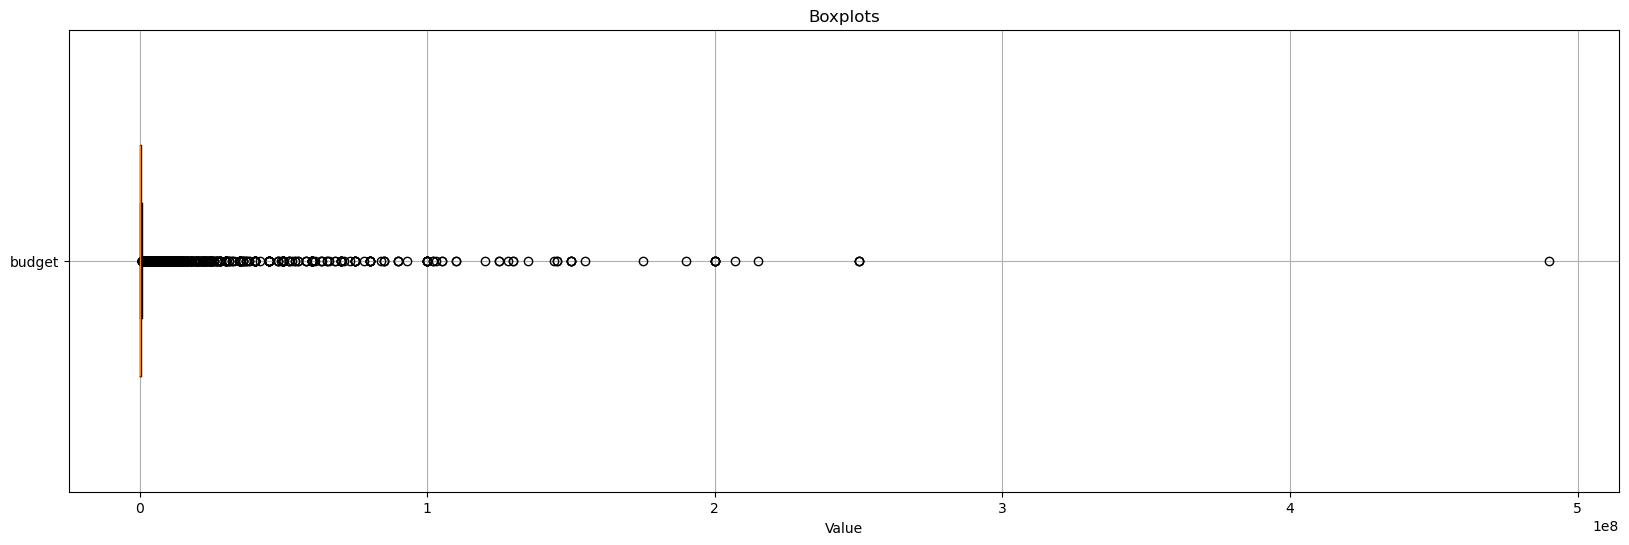

In [13]:
plot_boxplots(data=df_clean, columns=["budget"]) 

Минимальное значение:          -12.00
Среднее значение:              30111886.42
Среднеквадратичное отклонение: 101860180.01
Первый квартиль:               26565.00
Медиана:                       1397388.00
Третий квартиль:               13000000.00
Максимальное значение:         2068223624.00


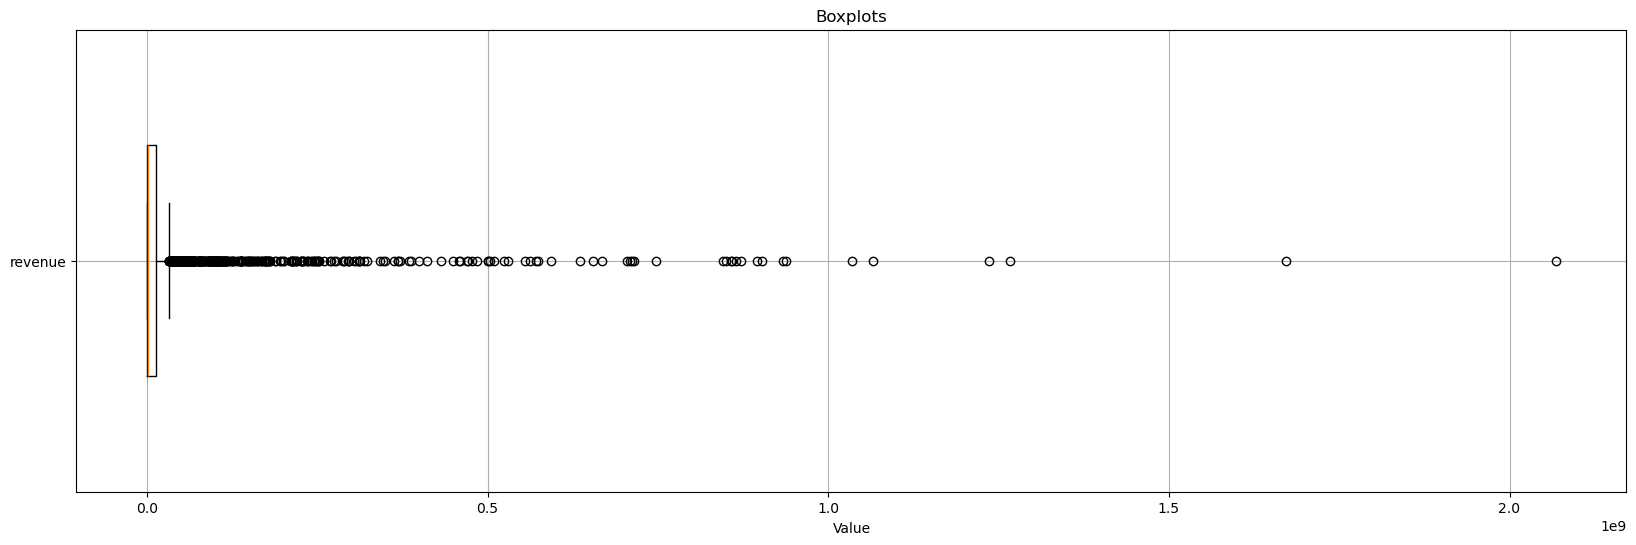

In [14]:
plot_boxplots(data=df_clean, columns=["revenue"])

Отрицательное значение revenue"-12" явно являетсся ошибкой, так как выручка не может быть отрицательной.  
Посмотрим много ли таких значений. Если оно одно, то это единичная ошибка, возможно, появившаяся при сборе данных

In [15]:
negative_count = df_clean.filter(col("revenue") < 0).count()
print(f"Количество строк с отрицательным revenue: {negative_count}")

Количество строк с отрицательным revenue: 1


In [ ]:
Одну строку с отрицательным значением (ошибкой) можно удалить.

In [16]:
df_clean = df_clean.filter(col("revenue") != -12)

Минимальное значение:          0.21
Среднее значение:              6.26
Среднеквадратичное отклонение: 1.15
Первый квартиль:               5.60
Медиана:                       6.40
Третий квартиль:               7.00
Максимальное значение:         10.00


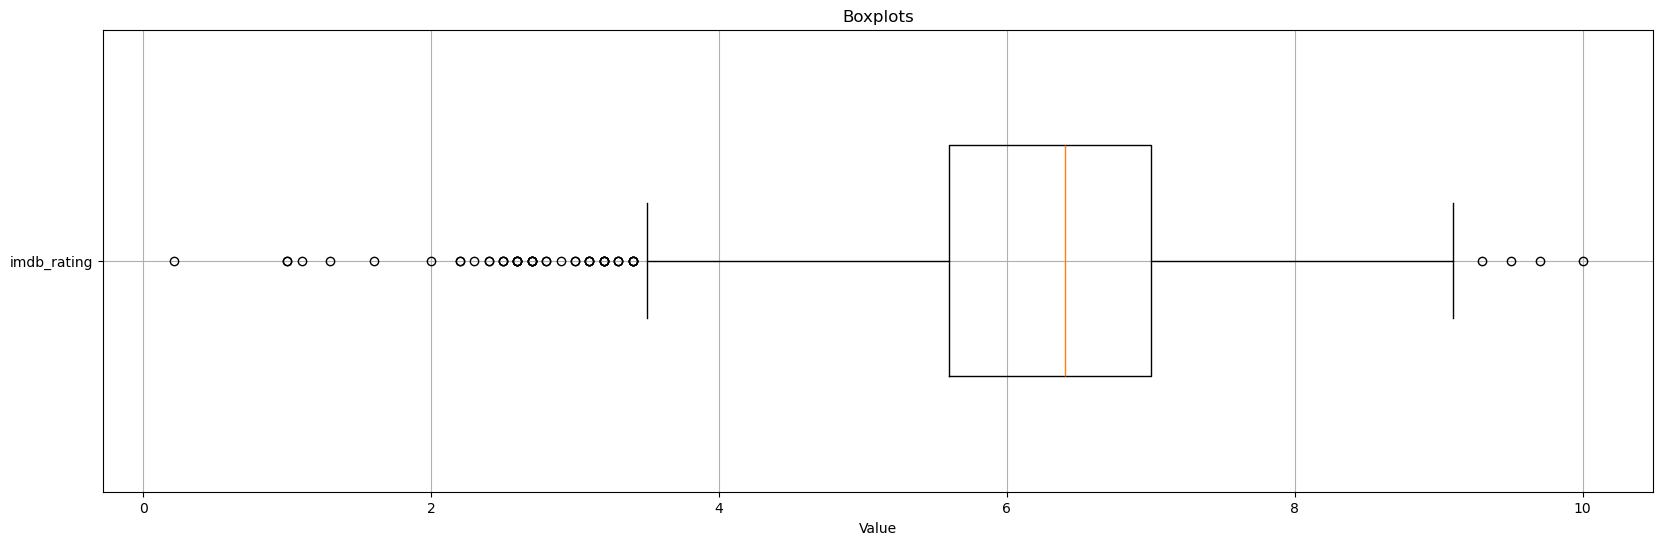

In [17]:
plot_boxplots(data=df_clean, columns=["imdb_rating"])

Минимальное значение:          1.00
Среднее значение:              47759.12
Среднеквадратичное отклонение: 136756.34
Первый квартиль:               882.00
Медиана:                       5803.00
Третий квартиль:               30497.00
Максимальное значение:         3163364.00


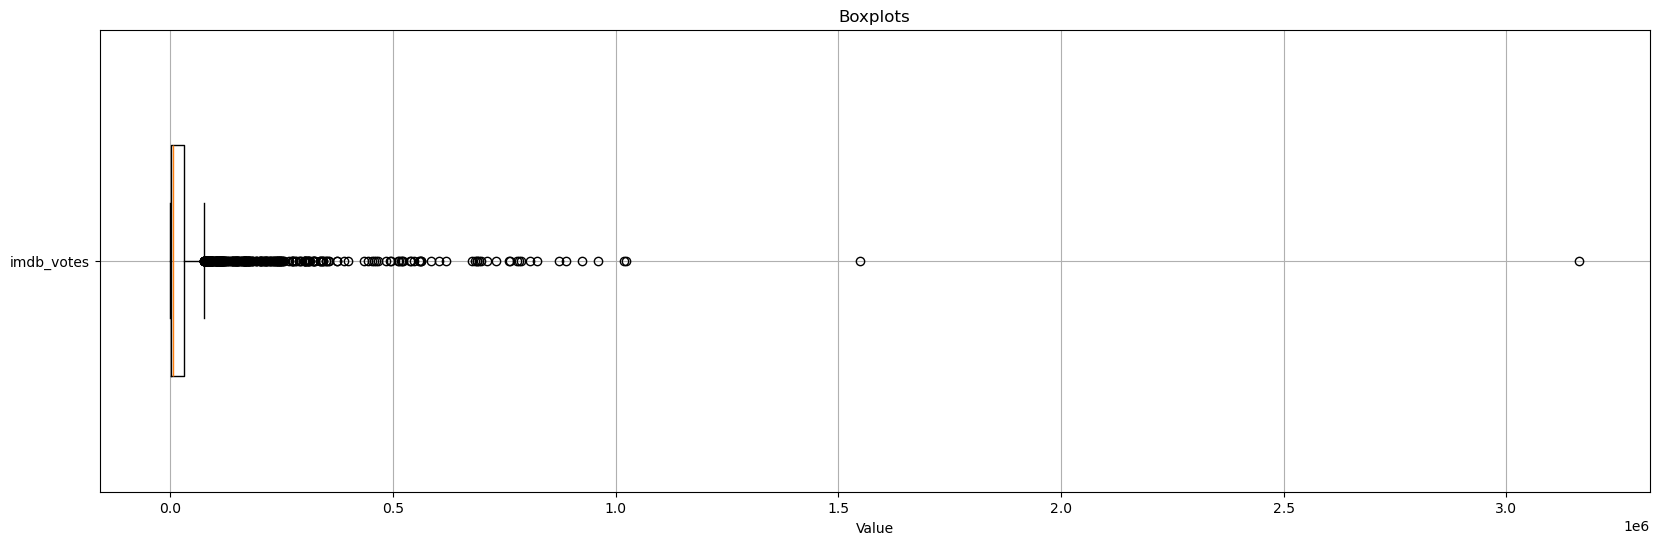

In [18]:
plot_boxplots(data=df_clean, columns=["imdb_votes"])

Минимальное значение:          1.00
Среднее значение:              904.56
Среднеквадратичное отклонение: 2415.41
Первый квартиль:               17.00
Медиана:                       116.00
Третий квартиль:               585.00
Максимальное значение:         39015.00


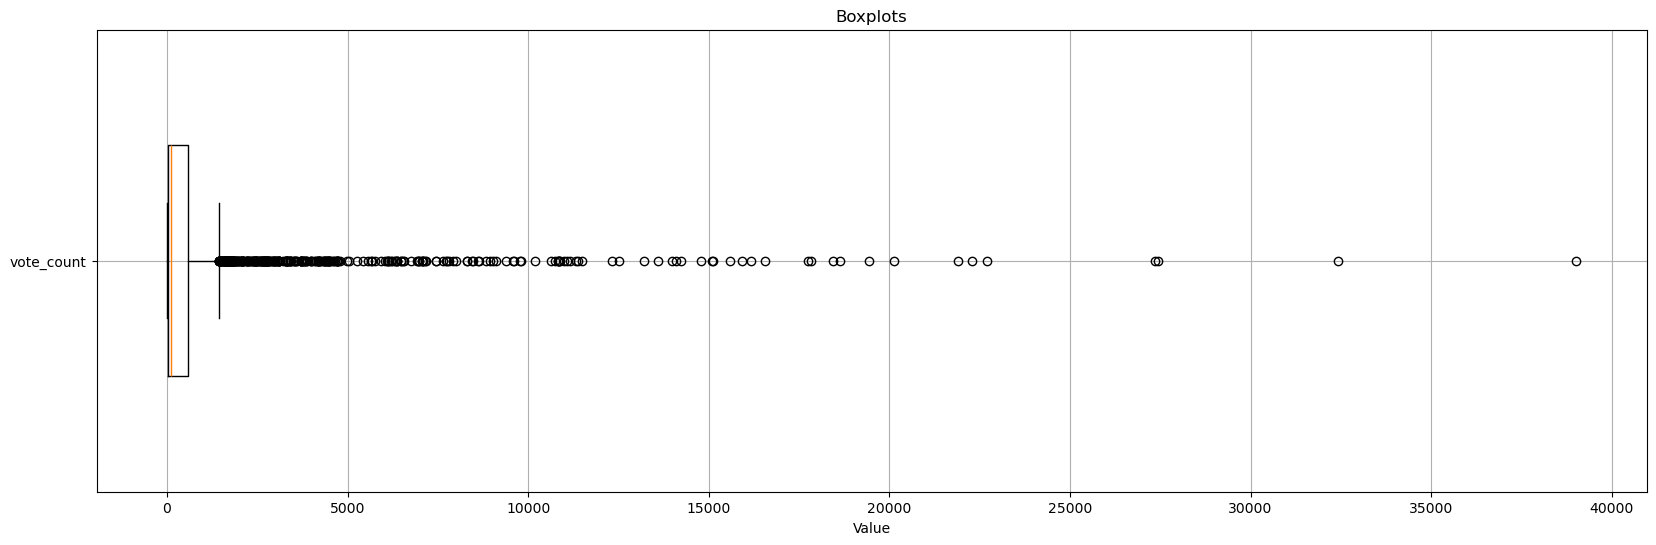

In [19]:
plot_boxplots(data=df_clean, columns=["vote_count"])

Минимальное значение:          0.50
Среднее значение:              6.44
Среднеквадратичное отклонение: 1.35
Первый квартиль:               5.77
Медиана:                       6.40
Третий квартиль:               7.05
Максимальное значение:         10.00


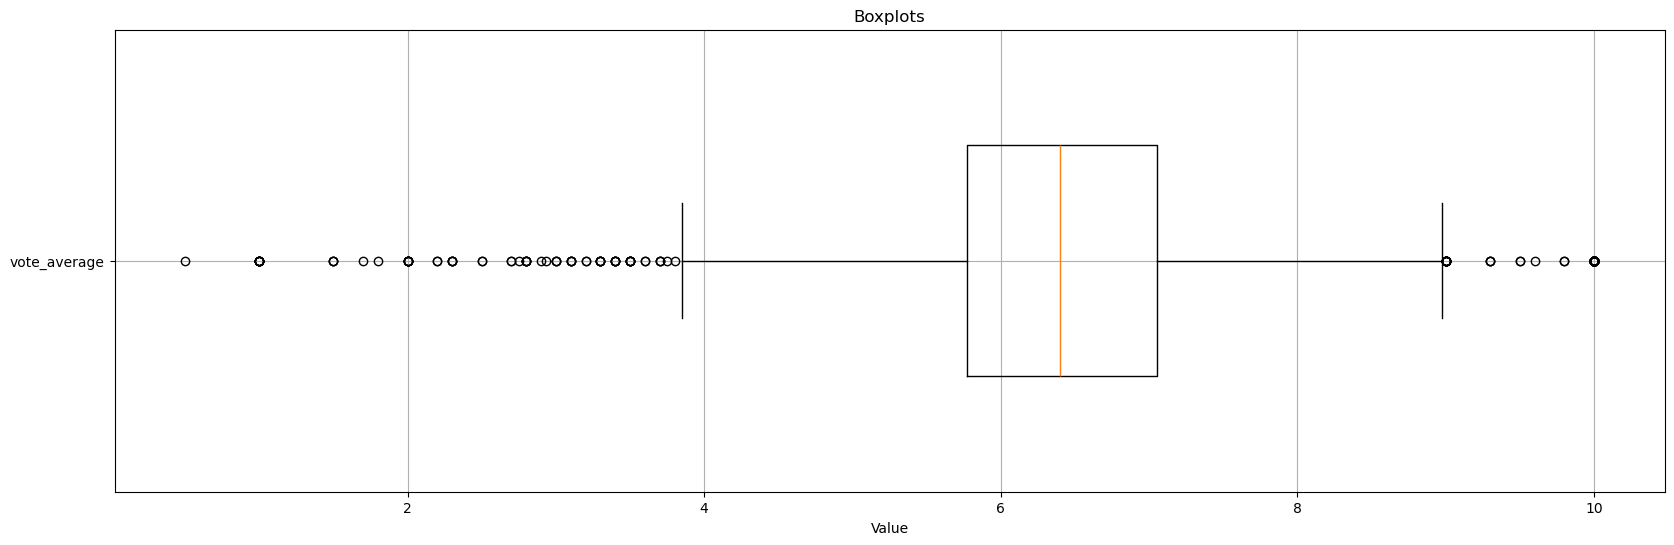

In [20]:
plot_boxplots(data=df_clean, columns=["vote_average"])

## Визуализациz распределения наиболее важных признаков

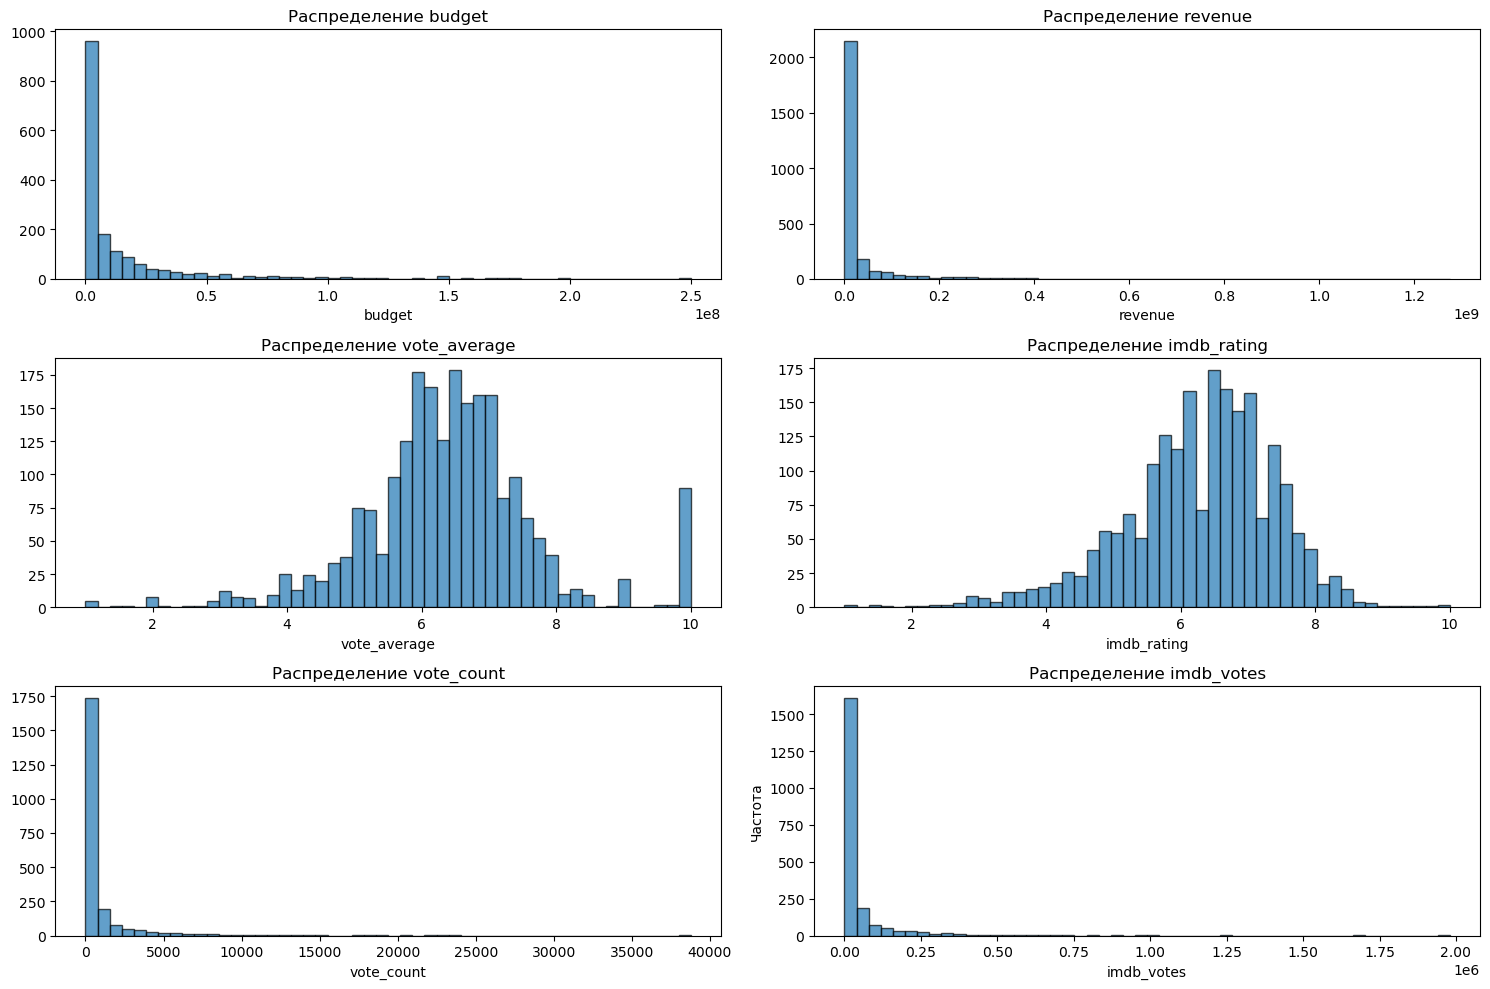

In [21]:
sample_df = df_clean.sample(False, 0.1, seed=42).toPandas() # Пересоздаём выборку после прошлых преобразований

plot_cols = ['budget', 'revenue', 'vote_average', 'imdb_rating', 'vote_count', 'imdb_votes'] # 3. Строим гистограммы

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for i, c in enumerate(plot_cols):
    data = sample_df[c].dropna() # Удаляем пропуски (null) перед построением
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7) # Строим гистограмму по отфильтрованным данным
    axes[i].set_title(f'Распределение {c}')
    axes[i].set_xlabel(c)
axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

В левой части гистограммы могут собираться фильмы с очень маленькими значениями.  
и визуально создаётся впечатление столбца на нуле.  
Это можно проверить, подсчитав количество нулей в каждой колонке

In [22]:
print("Количество нулей в budget:", df_clean.filter(col('budget') == 0).count())
print("Количество нулей в revenue:", df_clean.filter(col('revenue') == 0).count())
print("Количество нулей в runtime:", df_clean.filter(col('runtime') == 0).count())
print("Количество нулей в vote_average:", df_clean.filter(col('vote_average') == 0).count())
print("Количество нулей в imdb_rating:", df_clean.filter(col('imdb_rating') == 0).count())
print("Количество нулей в popularity:", df_clean.filter(col('popularity') == 0).count())
print("Количество нулей в imdb_votes:", df_clean.filter(col('imdb_votes') == 0).count())
print("Количество нулей в vote_count:", df_clean.filter(col('vote_count') == 0).count())

Количество нулей в budget: 0
Количество нулей в revenue: 0
Количество нулей в runtime: 0
Количество нулей в vote_average: 0
Количество нулей в imdb_rating: 0
Количество нулей в popularity: 0
Количество нулей в imdb_votes: 0
Количество нулей в vote_count: 0


Это подтверждает правостороннюю асимметрию данных и объясняет, почему на линейной шкале основная масса значений «сжимается» у нуля

## Корреляция между признаками.

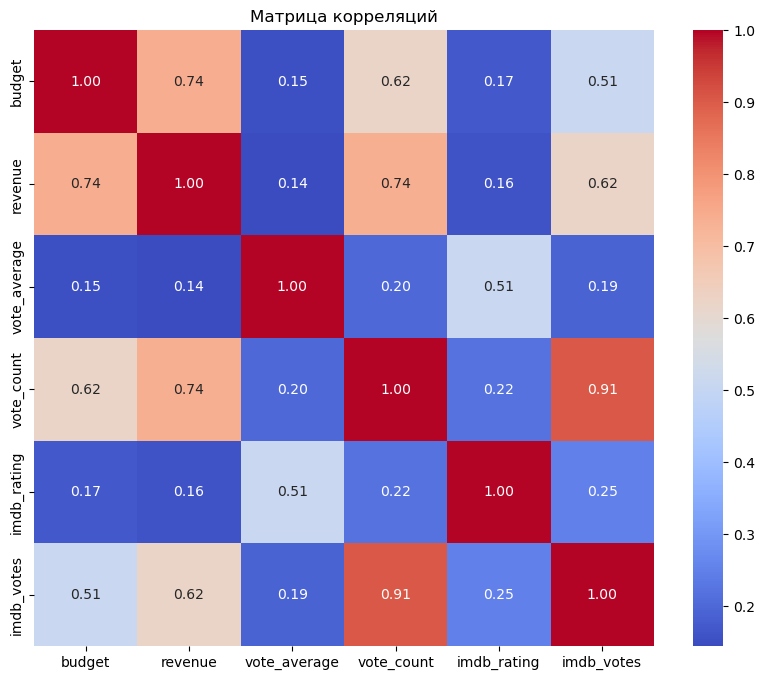

In [23]:
# Выберем числовые колонки для корреляции
corr_cols = ['budget', 'revenue', 'vote_average', 'vote_count', 'imdb_rating', 'imdb_votes',]

# Соберём корреляции в матрицу
corr_matrix = np.zeros((len(corr_cols), len(corr_cols)))
for i, col1 in enumerate(corr_cols):
    for j, col2 in enumerate(corr_cols):
        if i <= j:  
            corr_value = df_clean.stat.corr(col1, col2)
            corr_matrix[i, j] = corr_value
            corr_matrix[j, i] = corr_value  # симметрично

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', xticklabels=corr_cols, yticklabels=corr_cols, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()